In [133]:
import random
import matplotlib.pyplot as plt
W_max = 20
W_t = [0]*W_max
W_t[0] = 1
W = [W_t]

In [134]:
v = 2 
c = 4 
delta = 0.1
y = 10
T = 10

itération :  1
itération :  2
itération :  3
itération :  4
[0.5329375000000001, -0.47868750000000004, 0.23937500000000003, -0.051562500000000004, 0.00390625, -0.9573750000000001, 0.00012500000000006083, -0.7879375, 0.41000000000000003, -0.04843750000000001, 0.33921875, 0.505, 1.056875, 0.6543749999999999, 0.5821875, 0, 0, 0, 0, 0]


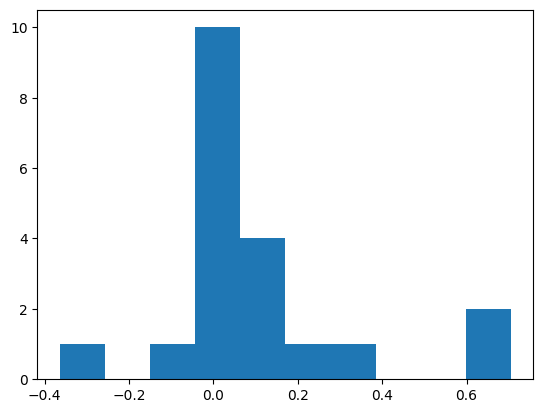

In [141]:
from copy import deepcopy
W_t = [0]*W_max
W_t[0] = 1
W = [deepcopy(W_t)]
for j in range(1,T):
    print("itération : ", j)
    W_t = deepcopy(W[j-1])
    for w,masse in enumerate(W[j-1]):
        if w< W_max - v - y:
            W_t[int(w + v/2 + y/2)] += 2*((1-v/c)**2) * masse
            W_t[int(w + v + y/2)] += 2*(v/c)*(1 - v/c)*masse
            W_t[int(w + y/2)] += 2*(v/c)*(1 - v/c)*masse
            W_t[int(w + v + y/2)] += ((v/c)**2)*masse
            W_t[int(w - c + y/2)] += ((v/c)**2) * masse
            W_t[w] -= 2*masse
            if w > 0:
                W_t[w] -= delta*masse
                W_t[0] += delta*masse
            elif w == 0 and j == 1:
                W_t[w] = 0
    if sum(W_t) != 2:
        print(W_t)
        break
        
    W.append(deepcopy(W_t))
  
    if W_t != W[j-1]:
        plt.clf()
        plt.hist(W[-1])
        plt.savefig(f"{j}.png")
    else:
        print("Chelou")

# Test plus simple

In [86]:
from copy import deepcopy
W_t = [0]*10
W_t[len(W_t)//2] = 1
W = [deepcopy(W_t)]
j = 1
for j in range(1,4):
    for w,masse in enumerate(W[j-1]):
        if masse != 0:
            try:
                W_t[w-1] += masse/2
                W_t[w+1] += masse/2
                W_t[w] -= masse
            except:
                pass
    W.append(deepcopy(W_t))
W[-1]


[0, 0, 0.125, 0.0, 0.375, 0.0, 0.375, 0.0, 0.125, 0]

In [81]:
W_t

[0, 0, 0, 0, 0.5, 0, 0.5, 0, 0, 0]

# Séparation 

In [ ]:
def p_g_cc(w):
    return int(max(0,w-y/2-v/2))
def p_g_ca(w):
    return int(max(0,w-y/2-v))
def p_g_ac(w):
    return int(max(0,w-y/2))
def p_g_aa(w):
    return int(max(0,w-y/2+c))
def D(w):
    if w == 0:
        return delta 

In [63]:
W_max = 1000
W_t = [0]*W_max
W_t[0] = 1
stop = 0
W = [W_t]
for j in range(1,10):
    print("itération : ", j)
    W_t = [0]*W_max
    for w in range(len(W_t)):
        #print("p_g_cc",p_g_cc(w))
        #print("p_g_ca",p_g_ca(w))
        #print("p_g_ac",p_g_ac(w))
        #print("p_g_aa",p_g_aa(w))
        W_t[w] =  (
            2*(1-v/c)**2 * W[j-1][p_g_cc(w)]
            + 2*v/c*(1 - v/c)*(W[j-1][p_g_ca(w)] + W[j-1][p_g_ac(w)]) 
            + (v/c)**2*(W[j-1][p_g_ca(w)] + W[j-1][p_g_aa(w)])
            - 2*W[j-1][w]- 1*(w == 0)*(delta*W[j-1][0] - delta) - 1*(w >0)*delta*W[j-1][w]
            )
        if W_t[w] < 0 or W_t[w]>1:
            print(2*(1-v/c)**2 * W[j-1][p_g_cc(w)])
            print(2*v/c*(1 - v/c)*(W[j-1][p_g_ca(w)] + W[j-1][p_g_ac(w)]))
            print((v/c)**2*(W[j-1][p_g_ca(w)] + W[j-1][p_g_aa(w)]))
            print(- 2*W[j-1][w])
            print(- 1*(w == 0)*(delta*W[j-1][0] - delta) - 1*(w >0)*delta*W[j-1][w])
            stop = 1
            break
        if stop == 1:
            break
    if stop == 1:
        break
        
    plt.hist(W_t)
    plt.savefig(f"{j}.png")
    W.append(W_t)

itération :  1
0.5
1.0
0.5
0
0.0
